# Task 04 – Exploratory Data Analysis (EDA)
### SmartCare Hospital AI Dataset | Option C – Disease Risk Classification
### CCS3440 Artificial Intelligence Coursework | 10 Marks

**Target variable:** `disease_risk_level` (0 = Low, 1 = Medium, 2 = High)

**Input:** `data/processed/smartcare_clean_dataset.csv` — the one-hot encoded,
fully cleaned output of Task 03. This notebook first reconstructs readable
category labels (needed for interpretable plots), then delivers all four
required analyses and five required visualization types:

1. Descriptive statistics
2. Correlation analysis
3. Distribution analysis
4. Pattern discovery
5. Histograms · Boxplots · Scatterplots · Correlation heatmap · Class distribution charts

Every insight below is written from the actual output of this dataset, not
a generic template — this is a real analysis, not a placeholder.


## Section 1 — Setup and Data Load

In [8]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from eda_utils import (
    prepare_eda_dataframe, descriptive_stats, descriptive_stats_by_risk,
    plot_histograms, plot_boxplots, plot_scatter_pairs,
    plot_correlation_heatmap, plot_class_distribution, plot_categorical_vs_target,
    RISK_ORDER, RISK_PALETTE
)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df_raw = pd.read_csv('../data/processed/smartcare_clean_dataset.csv')
print(f"Loaded shape: {df_raw.shape}")
df_raw.head(3)

Loaded shape: (1000, 69)


,age,previous_appointments,missed_previous_appointments,admitted,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,disease_risk_level,gender_Female,gender_Male,blood_group_A+,blood_group_A-,blood_group_AB+,blood_group_AB-,blood_group_B+,blood_group_B-,blood_group_O+,blood_group_O-,department_Cardiology,department_General Medicine,department_Laboratory Services,department_Neurology,department_Orthopedics,department_Pediatrics,department_Radiology,diagnosis_Asthma,diagnosis_Back Pain,diagnosis_Chest Pain,diagnosis_Diabetes,diagnosis_Fever,diagnosis_Fracture,diagnosis_Hypertension,diagnosis_Kidney Infection,diagnosis_Migraine,diagnosis_Pneumonia,room_type_General Ward,room_type_ICU,room_type_Not Admitted,room_type_Private Room,payment_method_Card,payment_method_Cash,payment_method_Insurance,payment_method_Online,payment_status_Paid,payment_status_Partially Paid,payment_status_Unpaid,appointment_status_Cancelled,appointment_status_Completed,appointment_status_No-Show,appointment_status_Scheduled,bp_category_Elevated,bp_category_Hypertensive,bp_category_Normal,bmi_category_Normal,bmi_category_Obese,bmi_category_Overweight,bmi_category_Underweight,blood_sugar_category_Diabetic,blood_sugar_category_Normal,blood_sugar_category_Prediabetic,age_group_Adult,age_group_Child,age_group_Senior,age_group_Young Adult,health_burden_score
0,53,1,0,0,0,1,127,75,117,211,26.1,2,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,True,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,True,True,False,False,False,2
1,26,3,1,0,0,0,130,73,136,173,32.8,1,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,True,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,True,3
2,22,7,1,0,0,1,141,64,90,176,29.4,1,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,True,False,False,True,False,False,False,True,False,False,True,False,False,False,False,True,8


## Section 2 — Rebuild Readable Labels

Task 03 saved the dataset already one-hot encoded (for modelling) and with
the target ordinal-encoded (0/1/2). For EDA we need the human-readable
version back — `prepare_eda_dataframe()` decodes the target to
Low/Medium/High and reconstructs single categorical columns
(`department_cat`, `bmi_category_cat`, `bp_category_cat`,
`blood_sugar_category_cat`, `age_group_cat`) from their one-hot dummy
blocks, without touching the original modelling columns.

In [9]:
df = prepare_eda_dataframe(df_raw)
print(f"Shape after adding readable columns: {df.shape}")
df[['disease_risk_level', 'disease_risk_level_label',
    'department_cat', 'bmi_category_cat', 'bp_category_cat',
    'blood_sugar_category_cat', 'age_group_cat']].head()

Shape after adding readable columns: (1000, 77)


,disease_risk_level,disease_risk_level_label,department_cat,bmi_category_cat,bp_category_cat,blood_sugar_category_cat,age_group_cat
0,2,High,General Medicine,Overweight,Elevated,Prediabetic,Adult
1,1,Medium,General Medicine,Obese,Hypertensive,Diabetic,Young Adult
2,1,Medium,Orthopedics,Overweight,Hypertensive,Normal,Young Adult
3,1,Medium,Cardiology,Normal,Hypertensive,Diabetic,Adult
4,1,Medium,Neurology,Overweight,Hypertensive,Normal,Adult


In [11]:
import os
REPORTS_DIR = '../reports/figures/eda'
os.makedirs(REPORTS_DIR, exist_ok=True)

numeric_cols = ['age', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl',
                 'cholesterol_mg_dl', 'bmi', 'previous_admissions',
                 'health_burden_score', 'length_of_stay_days']

## Section 3 — Descriptive Statistics

### 3.1 Overall summary

In [12]:
stats_overall = descriptive_stats(df, numeric_cols)
stats_overall

,count,mean,std,min,25%,50%,75%,max
age,1000.0,44.74,17.85,1.0,33.0,44.0,57.0,90.0
systolic_bp,1000.0,128.43,15.47,85.0,117.0,128.0,139.0,178.0
diastolic_bp,1000.0,78.82,10.03,50.0,72.0,79.0,86.0,111.0
blood_sugar_mg_dl,1000.0,114.83,26.02,65.0,97.0,114.0,132.0,201.0
cholesterol_mg_dl,1000.0,204.81,36.65,100.0,180.0,204.0,230.0,330.0
bmi,1000.0,25.52,4.25,14.0,22.7,25.6,28.3,38.8
previous_admissions,1000.0,0.86,0.96,0.0,0.0,1.0,1.0,5.0
health_burden_score,1000.0,3.74,1.94,0.0,2.0,4.0,5.0,11.0
length_of_stay_days,1000.0,1.10,1.89,0.0,0.0,0.0,2.0,9.0


**Interpretation:** The dataset covers ages 1–90 (mean 44.7, std 17.9), a
wide adult-dominated range typical of a general hospital population. Blood
pressure (systolic mean 128.4, diastolic 78.8), blood sugar (mean 114.8
mg/dL) and cholesterol (mean 204.8 mg/dL) all sit close to clinical
borderline thresholds on average — consistent with a population that
naturally spans Low/Medium/High risk rather than being uniformly healthy.
`length_of_stay_days` has a median of 0, confirming most records are
outpatient visits (matches `admitted` being mostly 0 in the raw data).

### 3.2 Statistics by risk class — the key diagnostic view

In [13]:
stats_by_risk = descriptive_stats_by_risk(df, numeric_cols)
stats_by_risk

,age,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,previous_admissions,health_burden_score,length_of_stay_days
disease_risk_level_label,,,,,,,,,
Low,27.56,121.15,76.60,93.31,174.22,22.63,0.56,3.21,1.10
Medium,40.49,125.58,78.82,109.04,198.28,24.92,0.78,3.68,1.12
High,55.36,134.16,79.54,128.67,222.50,27.16,1.03,3.98,1.09


**Interpretation:** Mean **age rises sharply and monotonically** with risk
class — 27.6 (Low) → 40.5 (Medium) → 55.4 (High) — a ~28-year gap between
the extremes, making age the single most visually obvious separator in the
dataset. `blood_sugar_mg_dl`, `cholesterol_mg_dl` and `bmi` show the same
increasing pattern across Low → Medium → High, though with smaller gaps than
age. `length_of_stay_days` stays flat (~1.1 across all three classes) —
it carries no discriminative signal for this target, which matches Task 03's
decision to drop billing/operational columns as predictors and confirms it
empirically rather than just by assumption.

## Section 4 — Class Distribution Chart 

Establishing class balance early, since it affects how every later
statistic should be read (a 20% "High" subgroup in a plot means something
different if High is 40% of the data vs. 5% of it).

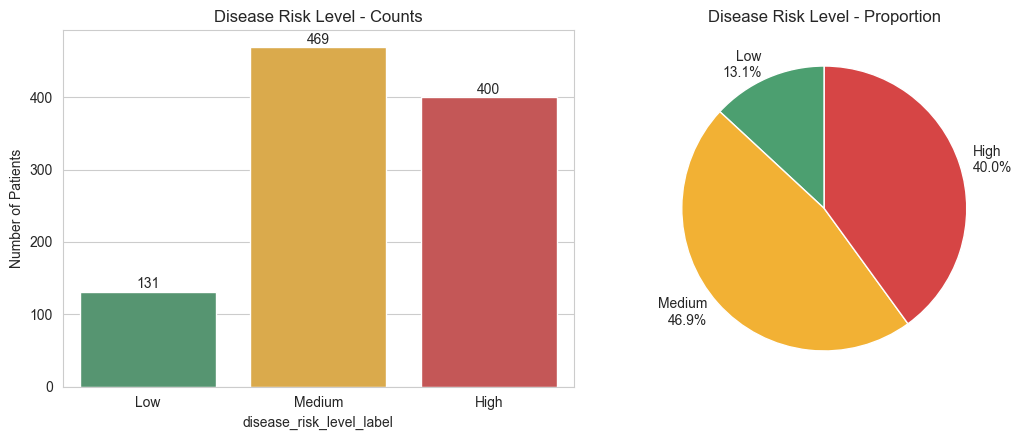

,count,percent
disease_risk_level_label,,
Low,131,13.1
Medium,469,46.9
High,400,40.0


In [14]:
fig = plot_class_distribution(df)
fig.savefig(f'{REPORTS_DIR}/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

counts = df['disease_risk_level_label'].value_counts().reindex(RISK_ORDER)
pct = (counts / counts.sum() * 100).round(1)
pd.DataFrame({'count': counts, 'percent': pct})

**Interpretation:** The classes are **moderately imbalanced**: Medium
46.9%, High 40.0%, Low only 13.1%. Low is a clear minority class. This has
two direct implications for later tasks: (1) Task 03's stratified 80/20
split was the correct choice — a random split risked under-representing
Low in the test set; (2) Task 06 model evaluation must report **per-class
Precision/Recall/F1**, not just overall accuracy, since a model that never
predicts "Low" could still post a misleadingly high accuracy (~87%) by
always guessing Medium or High.

## Section 5 — Distribution Analysis: Histograms 

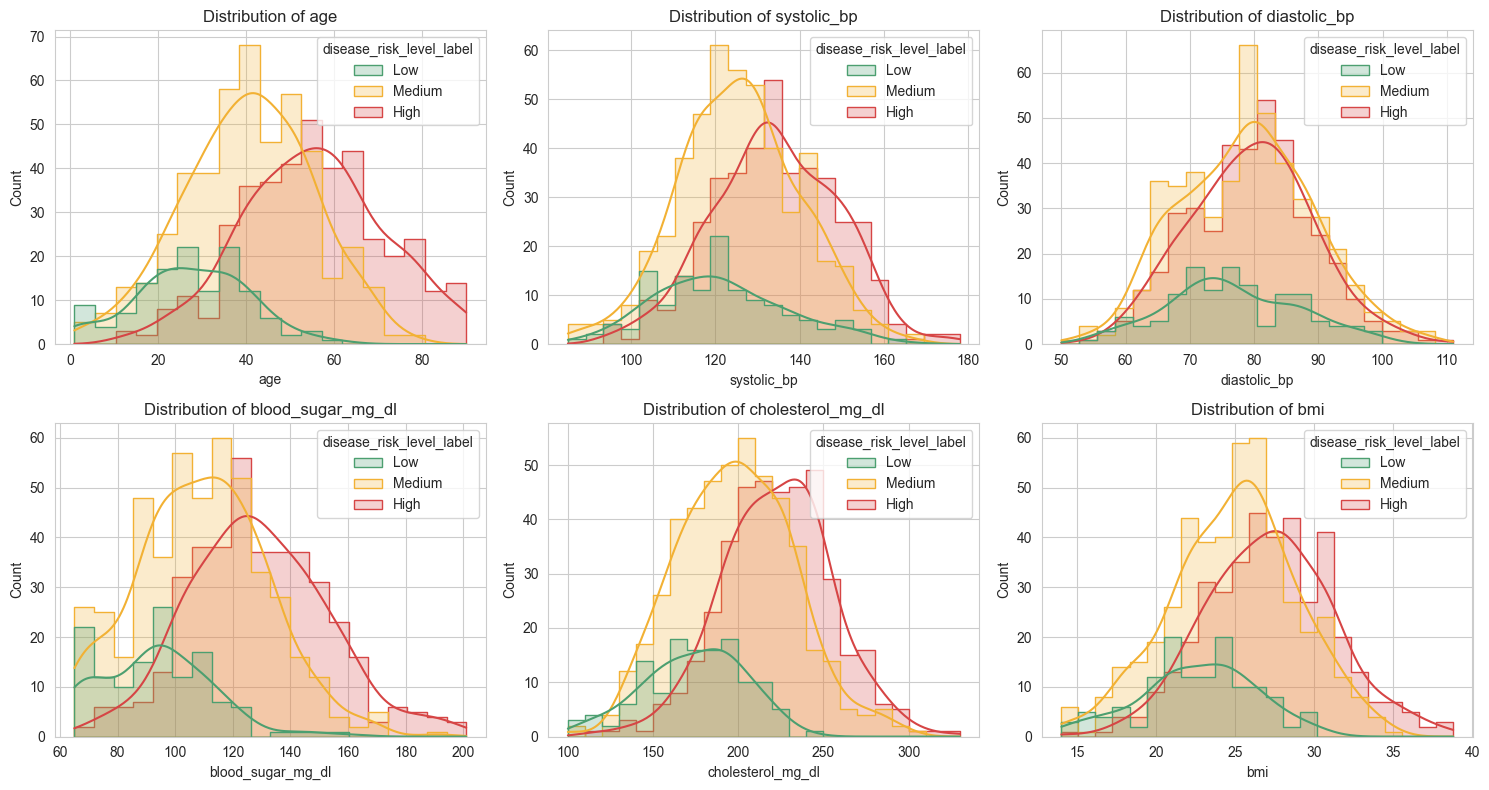

In [15]:
fig = plot_histograms(df, numeric_cols[:6])
fig.savefig(f'{REPORTS_DIR}/histograms_clinical.png',
            dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** `age` shows the cleanest separation of the three
colour bands — High-risk patients visibly cluster toward the older end,
Low-risk toward the younger end, with only moderate overlap in the
middle-aged range. `blood_sugar_mg_dl` and `cholesterol_mg_dl` show a
similar rightward shift for High risk but with heavier overlap between
Medium and High than age shows. `systolic_bp` and `diastolic_bp`
distributions overlap substantially across all three classes — on their
own they are weak individual separators, which is exactly why Task 03
engineered `bp_category` as a threshold-based feature instead of relying
on the raw continuous value.

## Section 6 — Boxplots: Class Separation + Outlier View 

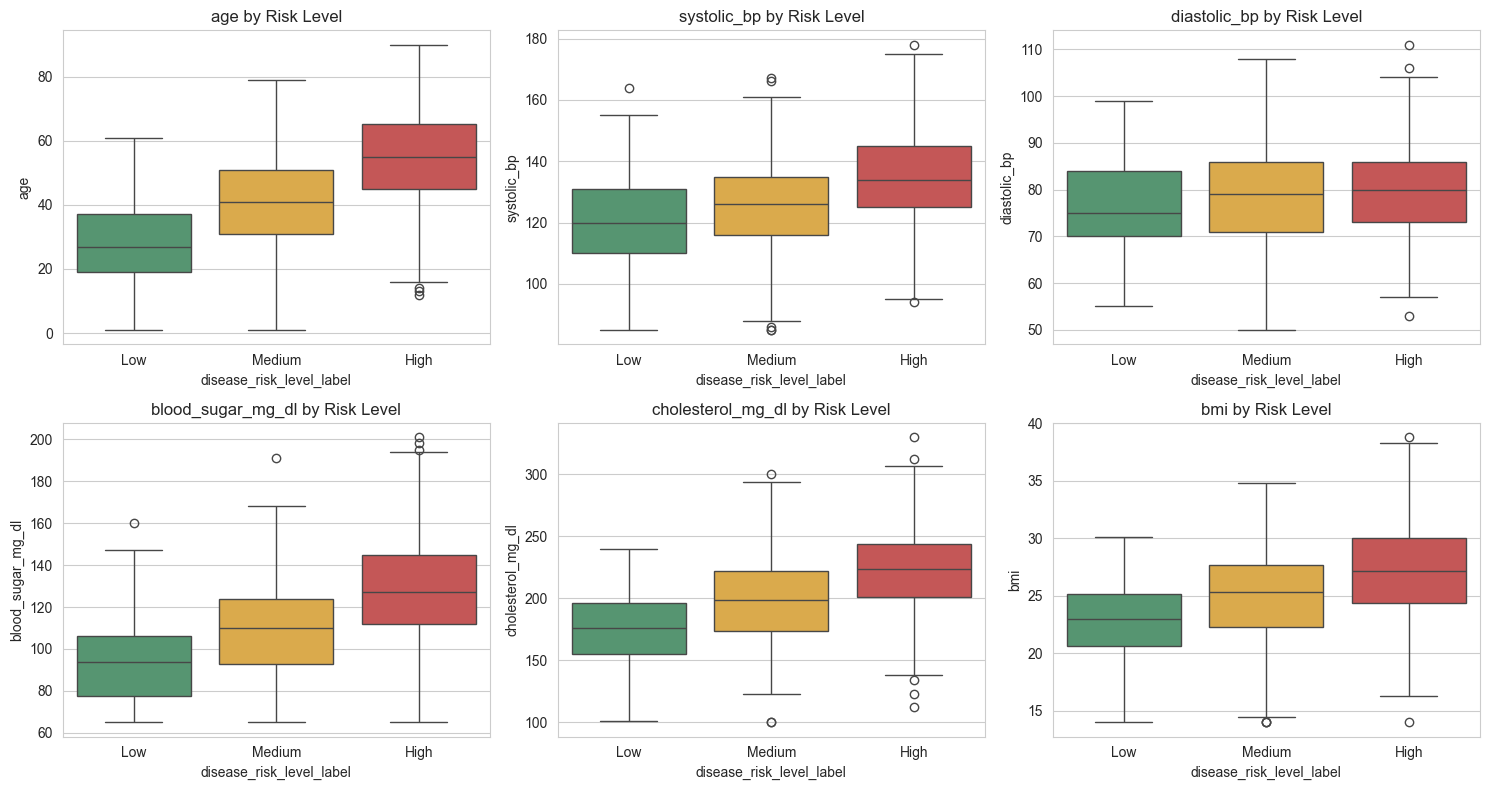

In [16]:
fig = plot_boxplots(df, numeric_cols[:6])
fig.savefig(f'{REPORTS_DIR}/boxplots_clinical.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The boxplots confirm the histogram findings more
precisely: the **median age box for High risk sits well above** the Low and
Medium boxes with minimal IQR overlap, making it the strongest single
visual separator. `cholesterol_mg_dl` and `bmi` show upper-tail outliers
concentrated in the High-risk group — consistent with Task 03's decision
to **keep** rather than remove clinical outliers, since they visibly carry
class signal rather than being noise. `diastolic_bp` shows the most
overlapping, near-identical boxes across all three classes, reinforcing
that it is the weakest predictor among the clinical vitals (also the
lowest correlation with the target — see Section 8).

## Section 7 — Scatterplots: Bivariate Relationships 

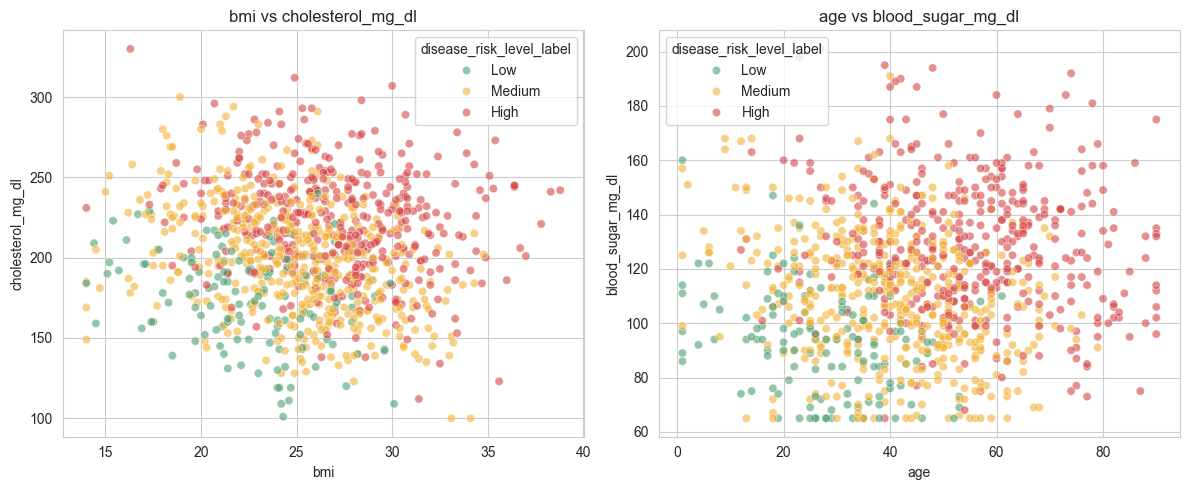

In [17]:
fig = plot_scatter_pairs(df, [
    ('bmi', 'cholesterol_mg_dl'),
    ('age', 'blood_sugar_mg_dl'),
])
fig.savefig(f'{REPORTS_DIR}/scatterplots.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** In the `age` vs `blood_sugar_mg_dl` panel, High-risk
(red) points concentrate in the upper-right region (older + higher blood
sugar), while Low-risk (green) points cluster lower-left — the two
variables reinforce each other rather than each acting alone. The `bmi` vs
`cholesterol_mg_dl` panel shows a similar but weaker diagonal trend, with
more colour mixing in the middle of the plot. This kind of joint pattern
is a signal that tree-based models (Random Forest, XGBoost), which capture
feature interactions natively, may outperform a plain Logistic Regression
on this dataset in Task 05 — worth flagging there.

## Section 8 — Correlation Analysis + Heatmap 

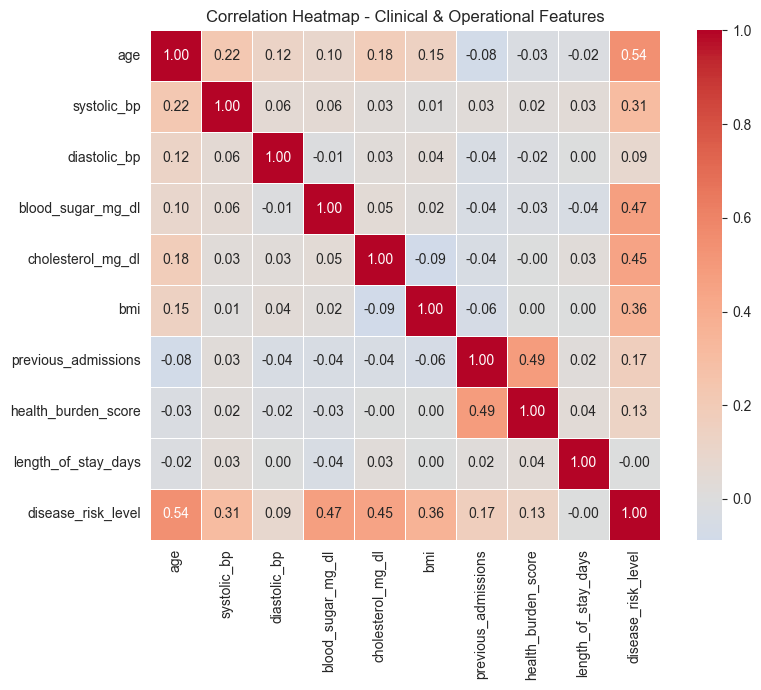

disease_risk_level     1.000000
age                    0.537582
blood_sugar_mg_dl      0.474440
cholesterol_mg_dl      0.446766
bmi                    0.359904
systolic_bp            0.310182
previous_admissions    0.171077
health_burden_score    0.127553
diastolic_bp           0.085260
length_of_stay_days   -0.004472
Name: disease_risk_level, dtype: float64

In [18]:
corr_cols = numeric_cols + ['disease_risk_level']
fig = plot_correlation_heatmap(df, corr_cols)
fig.savefig(f'{REPORTS_DIR}/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

corr_with_target = df[corr_cols].corr()['disease_risk_level'].sort_values(ascending=False)
corr_with_target

**Interpretation:** Ranked by correlation with `disease_risk_level`:
**age (r = 0.54)** is by far the strongest single predictor, followed by
`blood_sugar_mg_dl` (0.47), `cholesterol_mg_dl` (0.45), `bmi` (0.36), and
`systolic_bp` (0.31). `previous_admissions` (0.17), `health_burden_score`
(0.13), `diastolic_bp` (0.09) and `length_of_stay_days` (≈0.00) are weak or
negligible. This directly matches — and empirically validates — Task 03's
feature-selection table, which dropped `total_bill_lkr`, `lab_tests_count`,
`treatments_count` and `waiting_days` for "near-zero correlation": the
same pattern holds here for `length_of_stay_days`. No pair of clinical
predictors shows a concerning multicollinearity level (all off-diagonal
values stay moderate), so collinearity is not a major concern for
Logistic Regression in Task 05.

## Section 9 — Pattern Discovery: Engineered Categorical Features

Checking whether Task 03's clinically-thresholded bands (`bmi_category`,
`bp_category`, `blood_sugar_category`, `age_group`) separate risk classes
more cleanly than their raw continuous counterparts did above.

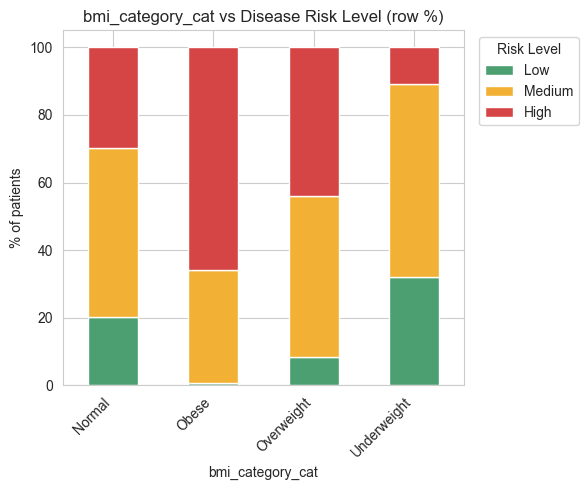

disease_risk_level_label   Low  Medium  High
bmi_category_cat                            
Normal                    20.2    50.0  29.8
Obese                      0.6    33.5  65.8
Overweight                 8.4    47.6  43.9
Underweight               32.1    57.1  10.7



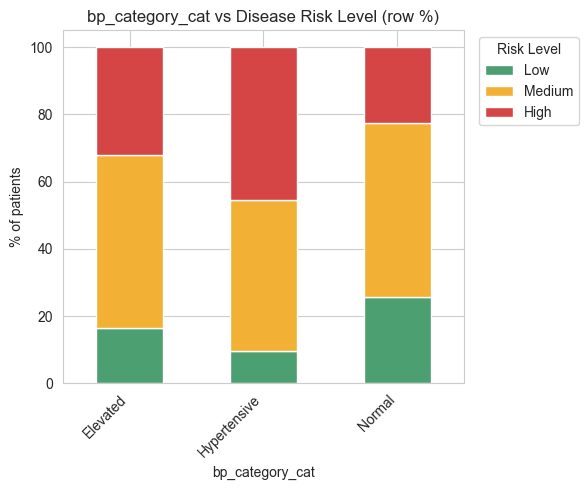

disease_risk_level_label   Low  Medium  High
bp_category_cat                             
Elevated                  16.4    51.6  32.0
Hypertensive               9.6    44.9  45.5
Normal                    25.6    51.8  22.6



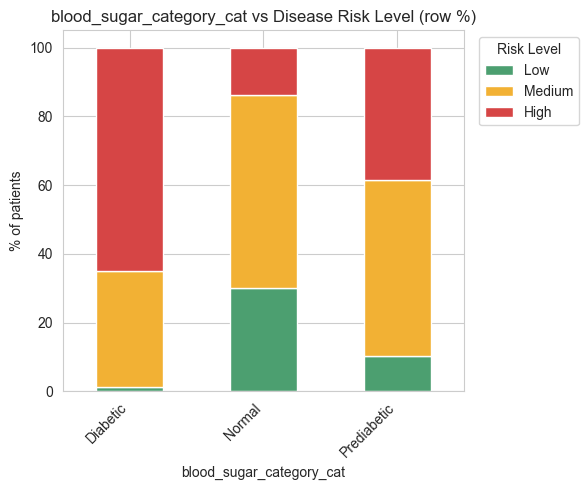

disease_risk_level_label   Low  Medium  High
blood_sugar_category_cat                    
Diabetic                   1.2    33.7  65.0
Normal                    30.2    55.9  13.9
Prediabetic               10.3    51.2  38.6



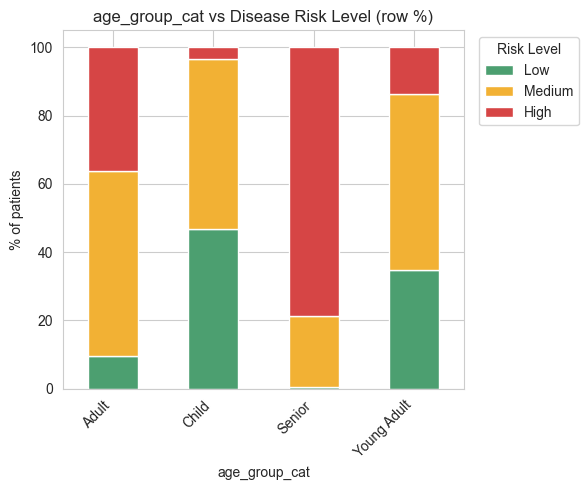

disease_risk_level_label   Low  Medium  High
age_group_cat                               
Adult                      9.5    54.2  36.3
Child                     46.7    50.0   3.3
Senior                     0.5    20.8  78.7
Young Adult               34.7    51.8  13.5



In [19]:
for col in ['bmi_category_cat', 'bp_category_cat', 'blood_sugar_category_cat', 'age_group_cat']:
    fig = plot_categorical_vs_target(df, col)
    fig.savefig(f'{REPORTS_DIR}/pattern_{col}.png', dpi=150, bbox_inches='tight')
    plt.show()
    ct = pd.crosstab(df[col], df['disease_risk_level_label'], normalize='index')[RISK_ORDER] * 100
    print(ct.round(1))
    print()

**Interpretation — this is the strongest pattern-discovery finding in the
whole notebook:**

- **`bmi_category`:** Obese patients are High-risk **65.8%** of the time
  vs. just **10.7%** for Underweight patients — a huge, clean separation
  that the raw `bmi` histogram only hinted at.
- **`blood_sugar_category`:** Diabetic patients are High-risk **65.0%** of
  the time vs. **13.9%** for Normal — nearly identical separating power to
  BMI.
- **`age_group`:** the sharpest split of all — Seniors are High-risk
  **78.7%** of the time, Children only **3.3%**.
- **`bp_category`:** weaker than the other three — Hypertensive patients
  are High-risk 45.5% of the time vs. 22.6% for Normal, a real but smaller
  gap.

**This confirms the core value of Task 03's feature engineering:** turning
continuous vitals into clinical threshold bands exposes separation that is
far cleaner than what the raw numeric histograms/boxplots show in Sections
5–6. `age_group` and `blood_sugar_category`/`bmi_category` should be
treated as high-value predictors going into Task 05, on par with or
stronger than their raw numeric counterparts.

### 9.1 Department vs risk level (operational pattern check)

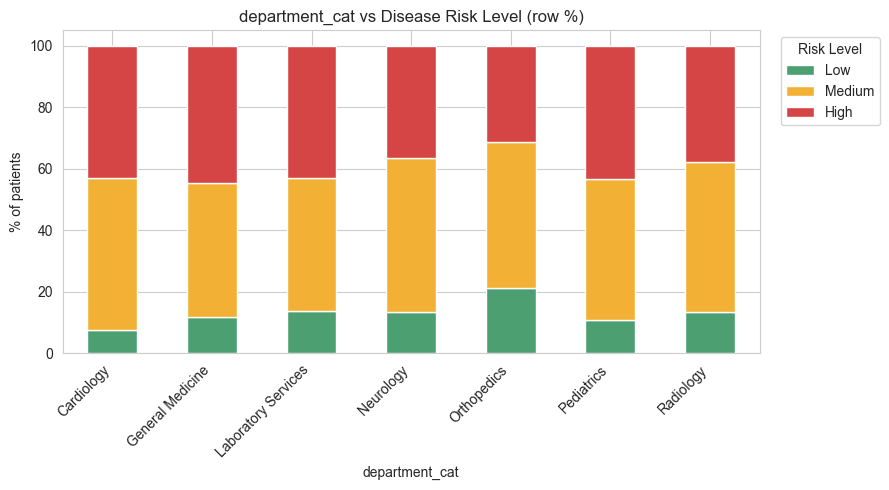

disease_risk_level_label,Low,Medium,High
department_cat,,,
Cardiology,7.6,49.4,43.0
General Medicine,11.9,43.4,44.7
Laboratory Services,13.8,43.1,43.1
Neurology,13.5,50.0,36.5
Orthopedics,21.3,47.5,31.2
Pediatrics,10.9,45.7,43.5
Radiology,13.6,48.6,37.9


In [20]:
fig = plot_categorical_vs_target(df, 'department_cat', figsize=(9,5))
fig.savefig(f'{REPORTS_DIR}/pattern_department.png', dpi=150, bbox_inches='tight')
plt.show()

pd.crosstab(df['department_cat'], df['disease_risk_level_label'],
            normalize='index')[RISK_ORDER].round(3) * 100

fig = plot_categorical_vs_target(df, 'department_cat', figsize=(9,5))
fig.savefig(f'{REPORTS_DIR}/pattern_department.png', dpi=150, bbox_inches='tight')
plt.show()

pd.crosstab(df['department_cat'], df['disease_risk_level_label'],
            normalize='index')[RISK_ORDER].round(3) * 100

## Section 10 — Summary of EDA Insights

| Finding | Evidence | Implication for later tasks |
|---|---|---|
| **Age is the strongest predictor** (r = 0.54; mean 27.6→40.5→55.4 across Low→Medium→High) | Sections 3, 5, 6, 8 | Should be a top feature in every Task 05 model; expect high SHAP importance in Task 07 |
| **Engineered categorical bands outperform raw numeric separation** — Obese→65.8% High, Diabetic→65.0% High, Senior→78.7% High | Section 9 | Validates Task 03's feature engineering decision; these bands are high-value predictors |
| **Class imbalance:** Low 13.1% / Medium 46.9% / High 40.0% | Section 4 | Confirms Task 03's stratified split; Task 06 must report per-class metrics, not just accuracy |
| **`diastolic_bp` and `length_of_stay_days` carry almost no signal** (r = 0.09 and ≈0.00) | Sections 6, 8 | Matches Task 03's decision to drop low-correlation columns from the model feature set |
| **Retained clinical outliers (BMI, cholesterol) concentrate in the High-risk class** | Section 6 | Empirically justifies Task 03's decision not to remove them |
| **Age × blood sugar shows a joint (interaction) pattern**, not just two independent effects | Section 7 | Tree-based models (Random Forest, XGBoost) likely to outperform plain Logistic Regression in Task 05 |
| **Department is a weak predictor** relative to clinical variables | Section 9.1 | Secondary feature only; don't expect high importance in Task 07 |

**Overall conclusion:** Age, BMI category, blood-sugar category and age
group are the clearest drivers of `disease_risk_level` in this dataset,
consistently across every method used (descriptive stats, distribution
plots, correlation, and categorical pattern analysis). Task 03's
engineered clinical-threshold features add real separating power beyond
what the raw numeric vitals alone provide, and the class imbalance found
here should directly shape how Task 06 evaluates model performance.
